In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:16pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 1절. 분류분석 개요
    - 데이터 속성을 활용하여, 데이터에 대한 분류기준을 수립하는 과정 타겟변수가 categorical인 분석
        ex. 고객등급예측, 휴면고객예측, 상품구매예측, 보험사기자예측.....
    -sklearn패키지
    -pip install scikit-learn
## 라이브러리의 데이터셋의 접근(3가지 방법)
### load계열(패키지안에 데이터가 내장)   
    -load_iris(), load_boston()...

### fetch 계열(패키지에 데이터가 없고, 인터넷연결하여 다운로드)
    - fetch_covtype() : 토지조사 데이터
    - fetch_20newgroups() : 뉴스텍스트 말뭉치......

### make 계열(새로운 데이터 셋 생성)
    - make_classification(): 분류분석용 가상의 데이터 생성
    - make_regression(): 회귀분석용 가상의 데이터 생성
     seaborn / tensorflow / sklearn

In [5]:
# load계열(패키지내에 데이터가 있음)
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
#MNIST 데이터셋 로드
(X_train,y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape,y_train.shape, X_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


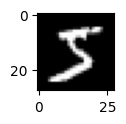

In [8]:
# 첫번째 숫자 이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X_train[0],cmap='gray')
plt.show()

In [ ]:
# fetch계열(인터넷 연결후 다운로드 c:/Users/내컴퓨터명/scikit_learn_data)

In [16]:
from sklearn.datasets import fetch_openml
import numpy as np
#MNIST데이터를 다운
mnist = fetch_openml(name='mnist_784',
                     version=1, #데이터 버전
                     as_frame=False, #False는 넘파이배열
                     parser='auto') # 파싱 방식을 sklearn이 자동결정

In [21]:
mnist

{'data': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int64),
 'target': array(['5', '0', '4', ..., '4', '5', '6'], dtype=object),
 'frame': None,
 'categories': {'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']},
 'feature_names': ['pixel1',
  'pixel2',
  'pixel3',
  'pixel4',
  'pixel5',
  'pixel6',
  'pixel7',
  'pixel8',
  'pixel9',
  'pixel10',
  'pixel11',
  'pixel12',
  'pixel13',
  'pixel14',
  'pixel15',
  'pixel16',
  'pixel17',
  'pixel18',
  'pixel19',
  'pixel20',
  'pixel21',
  'pixel22',
  'pixel23',
  'pixel24',
  'pixel25',
  'pixel26',
  'pixel27',
  'pixel28',
  'pixel29',
  'pixel30',
  'pixel31',
  'pixel32',
  'pixel33',
  'pixel34',
  'pixel35',
  'pixel36',
  'pixel37',
  'pixel38',
  'pixel39',
  'pixel40',
  'pixel41',
  'pixel42',
  'pixel43',
  'pixel44',
  'pixel45',
  'pixel46

In [31]:
X, y = mnist.data, mnist.target.astype(np.uint8) # y는 1byte짜리 양수int
X_reshaped=X.reshape(70000,28,-1)

In [27]:
X.shape, y.shape

((70000, 784), (70000,))

In [32]:
X_reshaped.shape

(70000, 28, 28)

In [34]:
X=X_reshaped

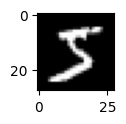

In [35]:
# 첫번째 숫자 이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X[0],cmap='gray')
plt.show()

# 2절. 분류분석의 종류

## 2.1 확률적 모형
- 주어진 데이터에 대해 각 클래스가 정답일 확률을 계산하는 모형
 - **predict_proba() : 각 분류 클래스가 될 확률들을 알려줌** (일부 판별함수모형에 있기는 함)
 - **predict_log_proba() : 확률의 로그값을알려줌**

### 1) 확률적 생성모형
- 각 클래스별 특징 데이터의 확률분포를 추정한 다음 베이즈 정리를 사용하여 확률 계산. 소량의 데이터로도 작동을 하는 경우
```
ex. sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis
    sklearn.naive_bayes.MultinomialNB

```

### 2) 확률적 판별모형
- 확률 함수를 추정하는 모형. 성능이 좋고, 해석이 쉬움
```
ex. sklearn.linear_model.LogisticRegression
    sklearn.tree.DecisionTreeClassifier(의사 결정나무) **분류에 영향을 주는 요인을 찾는데 더 많이 사용**
    
```

    
    
    
## 2.2 판별함수 모형
- 주어진 데이터를 클래스에 따라 서로 다른 영역으로 나누는 경계면을 찾은 후, 
  이 경계면으로 부터 데이터가 어느 위치에 있는 지 계산하는 판별함수를 이용하는 모형
 - **decision_function : 어떤 클래스로 분류되었는지를  알려줌**
 
```
ex. klearn.linear_model.Perceptron
    sklearn.svm.SVC
    sklearn.neural_network.MLPClassifier

```

=> RandomForest(배깅), XGboost, LGBM(부스팅), CatBoost등 앙상블 모형이 더 많이 사용됨

# 3절. 확률적 생성 모형
- 베이즈 정리를 사용한 확률분포 계산
## 3.1 QDA(QuadraticDiscriminantAnalysis)
- 독립변수 X가 실수이고, 정규분포라고 가정(pdf 11p)

In [75]:
#데이터 
from sklearn.datasets import make_classification  # 종속변수가 있는 data
X, y = make_classification(#n_samples=100, 데이터수(기본값)
                            n_features=2,    # 독립변수
                            n_informative=2, # 독립변수중 종속변수에 영향을 주는 변수 수
                            n_redundant=0,   # 독립변수끼리 선형관계가 있는 수(제외될 변수)
                            n_classes=2,     # 클래스 수
                            n_clusters_per_class=1, # 한 클래스당 군의 갯수
                            random_state=9,   # seed 값
                            weights=[0.5, 0.5]
)
X.shape, y.shape

((100, 2), (100,))

In [76]:
# y.mean() : 0과 1 클래스가 5:5 인지 확인
np.unique(y, return_counts=True)

(array([0, 1]), array([50, 50], dtype=int64))

In [67]:
# y가 0인 독립변수 X
X[y==0][:3]

array([[-0.73358502,  0.37658657],
       [-2.25158719,  3.59851363],
       [-0.6615633 ,  0.60245197]])

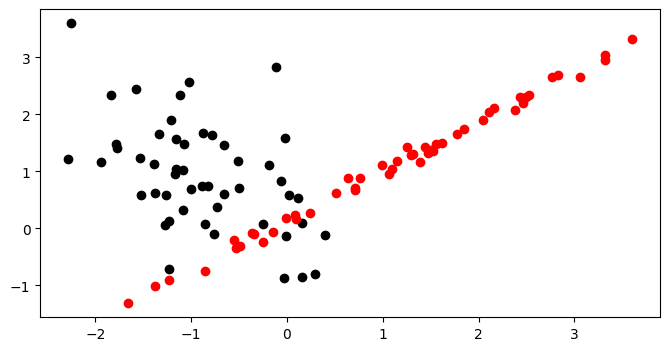

In [68]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']= (8,4)
plt.scatter(X[y==0,0],X[y==0,1], c='k')
plt.scatter(X[y==1,0],X[y==1,1], c='r')
plt.show()

In [131]:
# 대칭구조를 만듦
X[y==1] = -X[y==0]

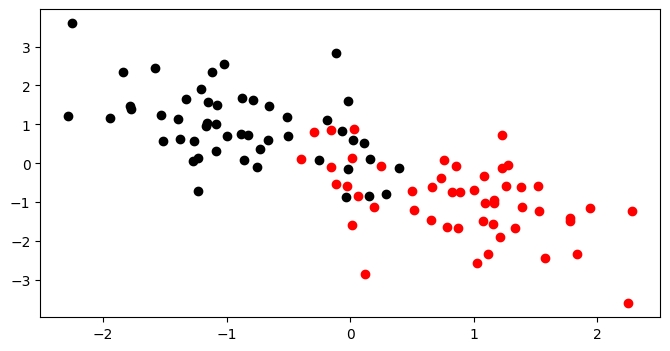

In [132]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']= (8,4)
plt.scatter(X[y==0,0],X[y==0,1], c='k')
plt.scatter(X[y==1,0],X[y==1,1], c='r')
plt.show()

In [133]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model =QuadraticDiscriminantAnalysis()
model.fit(X,y)

QuadraticDiscriminantAnalysis()

In [134]:
x = [[0,0]] # 입력데이터 2차원
p=model.predict_proba(x) #각 class가 될 확률
print(p) # 확률 2차원

[[0.5 0.5]]


In [116]:
model.predict(x)

array([1])

In [117]:
# 모델의 분류
model.classes_

array([0, 1])

In [122]:
# 교차표(혼동행렬)
import pandas as pd
y_hat=model.predict(X)
pd.crosstab(y,y_hat, colnames=['예측'],rownames=['실제'], margins=True)

예측,0,1,All
실제,,,
0,48,2,50
1,0,50,50
All,48,52,100


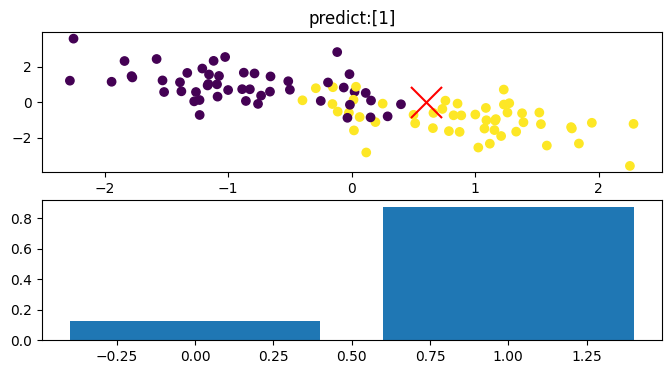

In [156]:
x = [[0.6,0]]
p =model.predict_proba(x)[0]
plt.subplot(211)#2행 1열로 subplot에서 첫번째 그래프
plt.scatter(x=X[:,0], y=X[:,1],c=y)
plt.scatter(x=x[0][0], y=x[0][1],c='r',marker='x',s=500)
h=model.predict(x)
plt.title(f'predict:{h}')
plt.subplot(212)
plt.bar(model.classes_,p)
plt.show()

## 3.2 나이브베이지안 모형
- MultinomialNB


In [158]:
import seaborn as sns
iris = sns.load_dataset('iris')
#학습데이터: 판다스 -> 넘파이배열

In [164]:
X=iris.iloc[:,:-1].values
y=iris.iloc[:,-1].values
# 모형 생성 및 학습
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X,y)

MultinomialNB()

In [166]:
x=[[5.1,3.5, 1.4,0.2]]
h = model.predict(x) # 예측값
p =model.predict_proba(x) # 각 클래스별 확률
print('예측:', h)
print(model.classes_)
print(p)

예측: ['setosa']
['setosa' 'versicolor' 'virginica']
[[0.75199536 0.16092948 0.08707516]]


<BarContainer object of 3 artists>

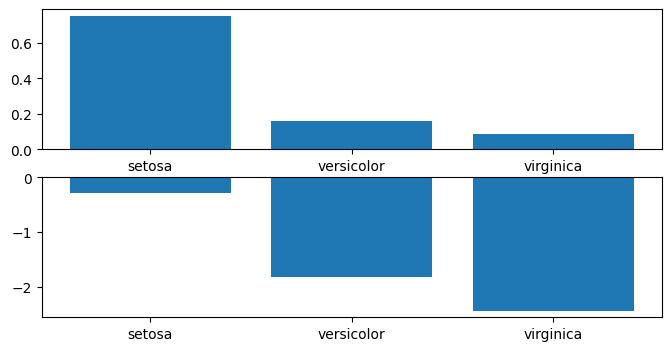

In [169]:
plt.subplot(211)
plt.bar(model.classes_, model.predict_proba(x)[0])
plt.subplot(212)
plt.bar(model.classes_, model.predict_log_proba(x)[0])

In [170]:
model.score(X,y) # 모델의 정확도


0.9533333333333334

## 4절. 모형2 확률적 판별모형
## 4.1 로지스틱 회귀모형(이진분류)
- 종속변수가 0 또는 1 인경우  

In [173]:
# 가상의 데이터 셋
X, y = make_classification(n_samples=100, # 데이터 갯수(행수)
                           n_features=1, # 독립변수 갯수 (기본값20)
                           n_informative=1, #제외될 독립변수 갯수(기본값2)
                           n_redundant=0, # 종속변수에 영향을 주는 독립변수 갯수 (기본값2)
                           n_classes=2,   # 종속변수의 클래스 수
                           n_clusters_per_class=1, #클래스당 군의 갯수(기본값2)
                           random_state=1
                           )
X.shape , y.shape

((100, 1), (100,))

In [174]:
np.c_[X,y][:3]

array([[-1.65902848,  0.        ],
       [-0.64202884,  0.        ],
       [-1.53918976,  0.        ]])

In [175]:
np.unique(y, return_counts=True)

(array([0, 1]), array([50, 50], dtype=int64))

In [177]:
# 모형
from sklearn.linear_model import LogisticRegression
model=LogisticRegression().fit(X,y)

In [185]:
x_data= np.linspace(-3,3,100)
#2차원 데이터를 만들기 위한 축확장
#x_data=x_data.reshape(-1,1)
x_data = x_data[:,np.newaxis]
#np.expand_dims(x_data,axis=1)
prob= model.predict_proba(x_data) #-3부터 0일확률과 1일 확률 

In [191]:
prob0=prob[:,0] # 0일 확률들
prob1=prob[:,1] # 1일 확률들

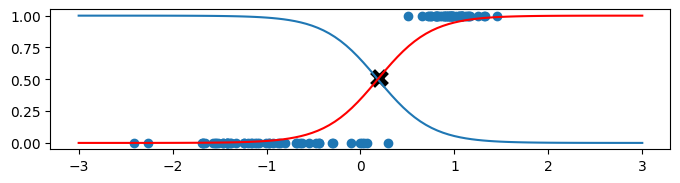

In [199]:
plt.subplot(2,1,1)
plt.scatter(X,y)
plt.plot(x_data,prob0)
plt.plot(x_data,prob1,c='r')
x=[[0.2]]
prob_x=model.predict_proba(x)[0]
plt.scatter(x[0], prob_x[1], marker='x', c='k', lw=5,s=100)
plt.show()

## 4-2 의사결정나무
- 여러가지 규칙을 순차적으로 적용하면서 독립변수 공간을 분할하는 분류 모형
- 종속변수에 영향을 주는 독립변수의 범주를 찾는 목적

In [200]:
from sklearn.datasets import load_iris
data=load_iris()
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [215]:
X = data.data
X = X[:,2:]
y = data.target
feature_names = [name[:-5] for name in data.feature_names[2:4]]
X.shape, y.shape, feature_names

((150, 2), (150,), ['petal length', 'petal width'])

In [216]:
from sklearn.tree import DecisionTreeClassifier
dt_model =DecisionTreeClassifier(criterion='entropy',  #트리의 분류품질기준을 entropy값으로  
                                max_depth=1,
                                random_state=0)
dt_model.fit(X,y)

DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0)

In [226]:
x_data= [[6,2.5]]
dt_model.predict(x_data)

array([1])

In [220]:
print(dt_model.classes_)
dt_model.predict_proba(x_data)

[0 1 2]


array([[1., 0., 0.]])

In [221]:
print(dt_model.score(X,y))

0.6666666666666666


In [222]:
dt_model5=DecisionTreeClassifier(criterion='entropy',
                                max_depth=5, #최대 나무 깊이
                                random_state=0)
dt_model5.fit(X,y)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

In [223]:
dt_model5.score(X,y)

0.9933333333333333

In [224]:
dt_model5.predict(x_data)

array([0])

In [225]:
dt_model5.predict_proba(x_data)

array([[1., 0., 0.]])